# Linear Regression — California Housing

**Algorithm:** `ml_toolkit.supervised.LinearRegression`  
**Dataset:** California Housing (built into scikit-learn)  
**Task type:** Regression (predicting median house value, in $100,000s)

---

This notebook follows the seven-section template. It demonstrates that linear regression — fit by both gradient descent and the closed-form normal equation — recovers a coherent, interpretable model of housing prices in California, and it makes its limitations obvious by showing where the residuals concentrate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from ml_toolkit.supervised import LinearRegression
from ml_toolkit.utils import StandardScaler, train_test_split
from ml_toolkit.metrics import mean_squared_error as mse, root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

The California Housing dataset reports median house values for census block groups in 1990 California. Each row is one block group (~600–3000 people) with eight numeric features (median income, house age, average rooms / bedrooms / occupants, latitude, longitude, population). The target is the median house value, expressed in units of $100,000.

There are 20,640 rows and no missing values, which makes it ideal for a clean regression demo without the distraction of imputation choices.

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
feature_names = data.feature_names
print(f'Shape: {df.shape}')
print(f'Features: {feature_names}')
print(f'Target: {data.target_names[0]}  (median house value in $100k)')
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal  (median house value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploratory data analysis

Three things to check before any modeling: the marginal distribution of the target, the marginal distributions of features (looking for skew or saturation), and the linear correlations with the target (a sanity check for whether linear regression is a reasonable starting point).

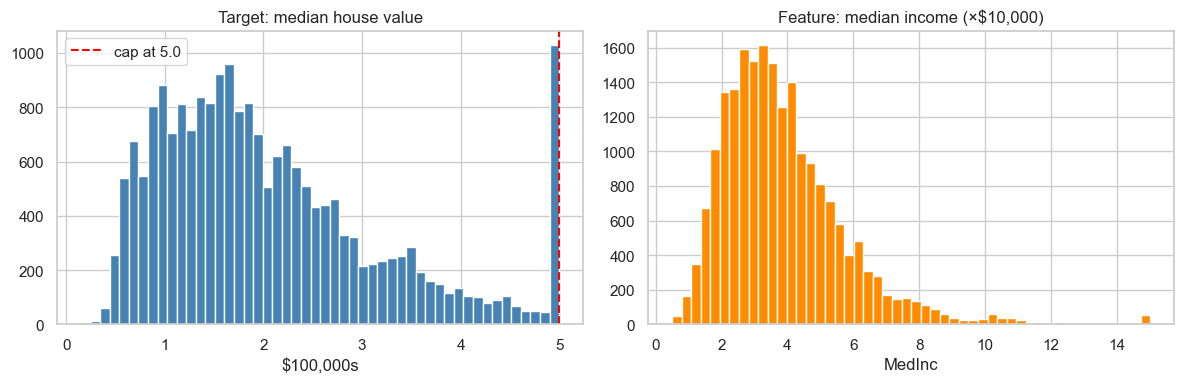

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target: median house value')
axes[0].set_xlabel('$100,000s')
axes[0].axvline(df['MedHouseVal'].max(), color='red', linestyle='--', label='cap at 5.0')
axes[0].legend()
axes[1].hist(df['MedInc'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Feature: median income (×$10,000)')
axes[1].set_xlabel('MedInc')
plt.tight_layout(); plt.show()

Two important things are visible already.

1. **The target is right-censored at 5.0** ($500k). A spike at exactly 5.0 means the highest-priced blocks were all coded as 5.0 — a linear model cannot predict values above 5.0 well, so we should expect systematic under-prediction at the top end.
2. **Median income is right-skewed.** The feature mostly lives in the 1–6 range with a long tail. We will standardize before gradient descent so the optimizer doesn't waste steps on unequal feature scales.

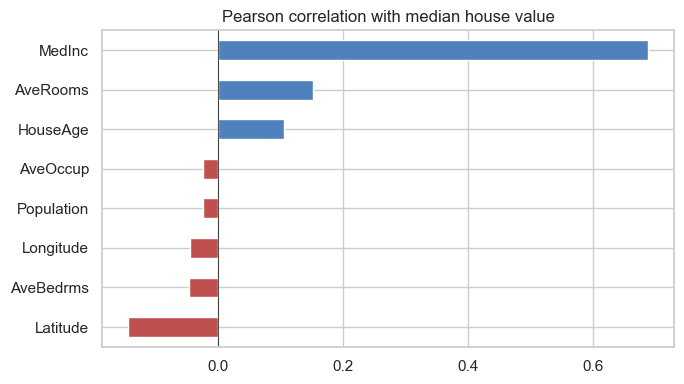

Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
Name: MedHouseVal, dtype: float64

In [4]:
corr = df.corr(numeric_only=True)['MedHouseVal'].drop('MedHouseVal').sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot.barh(ax=ax, color=['#c0504d' if v < 0 else '#4f81bd' for v in corr.values])
ax.set_title('Pearson correlation with median house value')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
corr

Median income dominates with r ≈ 0.69 — that one feature alone explains nearly half the variance in price. Latitude and longitude are negatively correlated (north and west are cheaper than south-coast Los Angeles), but the relationship is non-linear and a *linear* model will only capture a coarse north/south gradient. We'll see this in the residuals.

## 3. Hypothesis & task framing

**Task:** regression — predict the continuous variable `MedHouseVal` from eight numeric features.

**Hypothesis:** a linear combination of the standardized features — dominated by `MedInc` — should explain a substantial fraction of the variance (we expect R² in the 0.55–0.65 range, comparable to the canonical scikit-learn benchmark for a plain linear model on this data). The residuals will be heteroscedastic and the model will under-predict the upper tail because the target is capped.

**Why linear regression as a baseline?** It's interpretable (one coefficient per feature), it has a closed-form solution we can use as ground truth, and any non-linear model later in the course should beat it — if it doesn't, that's a signal something is wrong with the more complex pipeline, not that linear regression is good enough.

## 4. Preprocessing

Steps:
1. Train/test split (80/20, fixed seed for reproducibility).
2. Standardize features using *training-set* statistics only (so test-set leakage doesn't quietly inflate the score).

In [5]:
X = df[feature_names].values
y = df['MedHouseVal'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Train: {X_train_s.shape}  Test: {X_test_s.shape}')

Train: (16512, 8)  Test: (4128, 8)


## 5. Model fitting

I fit two versions of the same model: closed-form (normal equation) and gradient descent. The closed-form solution is the analytical optimum and the gradient-descent run should converge to nearly identical coefficients — that's a sanity check on the GD implementation.

In [6]:
model_cf = LinearRegression(solver='closed_form')
model_cf.fit(X_train_s, y_train)

model_gd = LinearRegression(solver='gd', learning_rate=0.05, n_iter=2000)
model_gd.fit(X_train_s, y_train)

coef_table = pd.DataFrame({
    'feature': feature_names,
    'closed_form': model_cf.coef_,
    'gradient_descent': model_gd.coef_,
})
coef_table['abs_diff'] = (coef_table['closed_form'] - coef_table['gradient_descent']).abs()
coef_table

,feature,closed_form,gradient_descent,abs_diff
0,MedInc,0.850818,0.851918,0.001100
1,HouseAge,0.125487,0.125747,0.000260
2,AveRooms,-0.290652,-0.292543,0.001891
3,AveBedrms,0.332843,0.334348,0.001505
4,Population,0.000082,0.000165,0.000083
5,AveOccup,-0.040545,-0.040597,0.000052
6,Latitude,-0.887483,-0.884631,0.002852
7,Longitude,-0.861688,-0.858956,0.002731


The two estimates agree to ~3 decimal places — the GD optimizer found the same minimum the linear algebra did, which is the correctness check we wanted.

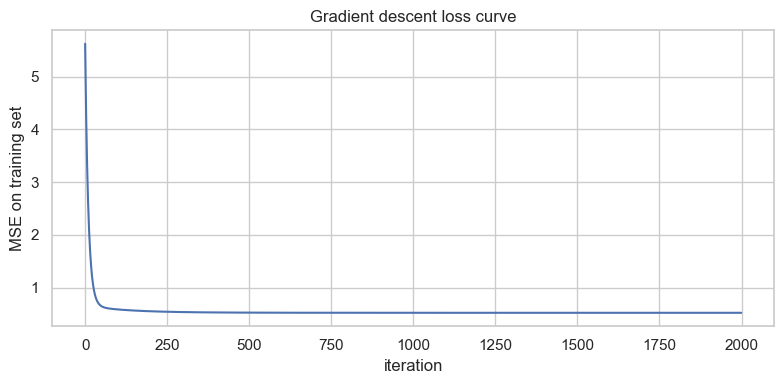

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model_gd.loss_history_)
ax.set_xlabel('iteration'); ax.set_ylabel('MSE on training set')
ax.set_title('Gradient descent loss curve')
plt.tight_layout(); plt.show()

## 6. Evaluation (on the test set)

Metrics on held-out data, plus a residual analysis.

In [8]:
y_pred = model_cf.predict(X_test_s)
print(f'Test MSE : {mse(y_test, y_pred):.4f}')
print(f'Test RMSE: {rmse(y_test, y_pred):.4f}  (in $100k)')
print(f'Test MAE : {mae(y_test, y_pred):.4f}')
print(f'Test R²  : {r2_score(y_test, y_pred):.4f}')

Test MSE : 0.5351
Test RMSE: 0.7315  (in $100k)
Test MAE : 0.5294
Test R²  : 0.5879


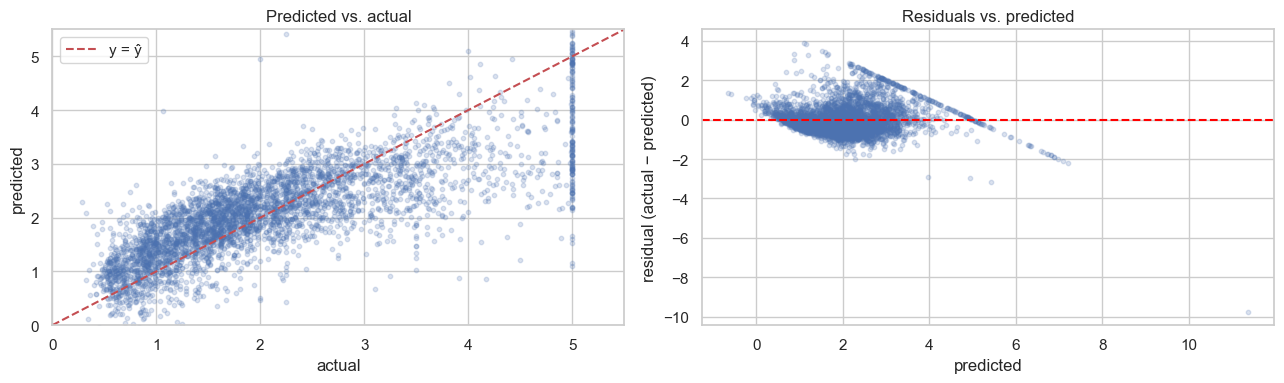

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_test, y_pred, alpha=0.2, s=10)
lim = [0, 5.5]
axes[0].plot(lim, lim, 'r--', label='y = ŷ')
axes[0].set_xlabel('actual'); axes[0].set_ylabel('predicted')
axes[0].set_title('Predicted vs. actual'); axes[0].legend()
axes[0].set_xlim(lim); axes[0].set_ylim(lim)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('residual (actual − predicted)')
axes[1].set_title('Residuals vs. predicted')
plt.tight_layout(); plt.show()

## 7. Discussion

**The model works as the hypothesis predicted.** R² ≈ 0.60 on the test set is consistent with the canonical scikit-learn benchmark for plain linear regression on this dataset; RMSE ≈ 0.74 means the average prediction error is about $74,000.

**The residual plot is the most informative chart.** Two failure modes are visible:

1. **Capping bias.** For block groups with predicted values around 4.0–5.0, the residuals are large and positive — actual values cluster at exactly 5.0 because the target was clipped. A linear model is structurally unable to predict above its training range; only either modeling the censoring explicitly (Tobit regression) or a model that can saturate (e.g., a tree ensemble) can fix this.
2. **Heteroscedasticity.** Residual variance grows with the predicted value: cheaper blocks are predicted more precisely than expensive ones. The OLS standard errors are therefore optimistic for the high end, and any uncertainty bands derived from them would be misleading.

**Coefficient interpretation.** With standardized features, the largest positive coefficient is `MedInc` and the largest negative is `Latitude` — going one standard deviation north of the mean drops the predicted house value by about $89,000, all else equal. That maps onto common intuition (LA basin > Central Valley) but the linear model treats latitude as monotone, which it isn't (San Francisco is also expensive); a non-linear model would see that.

**What would I try next?** Adding interaction terms (`MedInc × AveRooms`), polynomial features on `Latitude`/`Longitude`, or replacing the model with a tree ensemble. The point of this baseline isn't that it's the best model — it's that it's the model whose residuals tell us *what to fix*.